In [ ]:
# 1. On connecte Google Drive pour récupérer le Zip du dataset
from google.colab import drive
drive.mount('/content/drive')

# 2. On installe YOLO
!pip install ultralytics

# 3. On dézippe les données
import zipfile
import os

zip_path = "/content/drive/MyDrive/portion_fred/dataset_split.zip"
extract_path = "/content/dataset_split/" # Definir extract_path here

print(" Décompression en cours... (ça va vite)")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Données prêtes dans le Colab !")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:00
 Décompression en cours... (ça va vite)
✅ Données prêtes dans le Colab !


In [ ]:
from ultralytics import YOLO

# 1. Chargement du modèle
model = YOLO('yolov8n.pt')

# 2. Lancement de l'entraînement
print(" Démarrage de l'entraînement...")
results = model.train(data='/content/data.yaml', epochs=20, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Démarrage de l'entraînement...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=F


image 1/1 /content/dataset_split/dataset_split/images/test/Video_1_frame_15233181.png: 384x640 1 drone, 8.4ms
Speed: 1.4ms preprocess, 8.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict_image_03

image 1/1 /content/dataset_split/dataset_split/images/test/Video_0_frame_103832295.png: 384x640 1 drone, 5.5ms
Speed: 1.4ms preprocess, 5.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict_image_13

image 1/1 /content/dataset_split/dataset_split/images/test/Video_3_frame_20499795.png: 384x640 1 drone, 5.6ms
Speed: 1.4ms preprocess, 5.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict_image_23

--- RÉSULTATS VISUELS ---
Error: Predicted image not found at expected path: /content/runs/detect/predict_image_03/Video_1_frame_15233181.png
Found image at: /content/runs/detect/predict_image_03/Video_1_frame_15

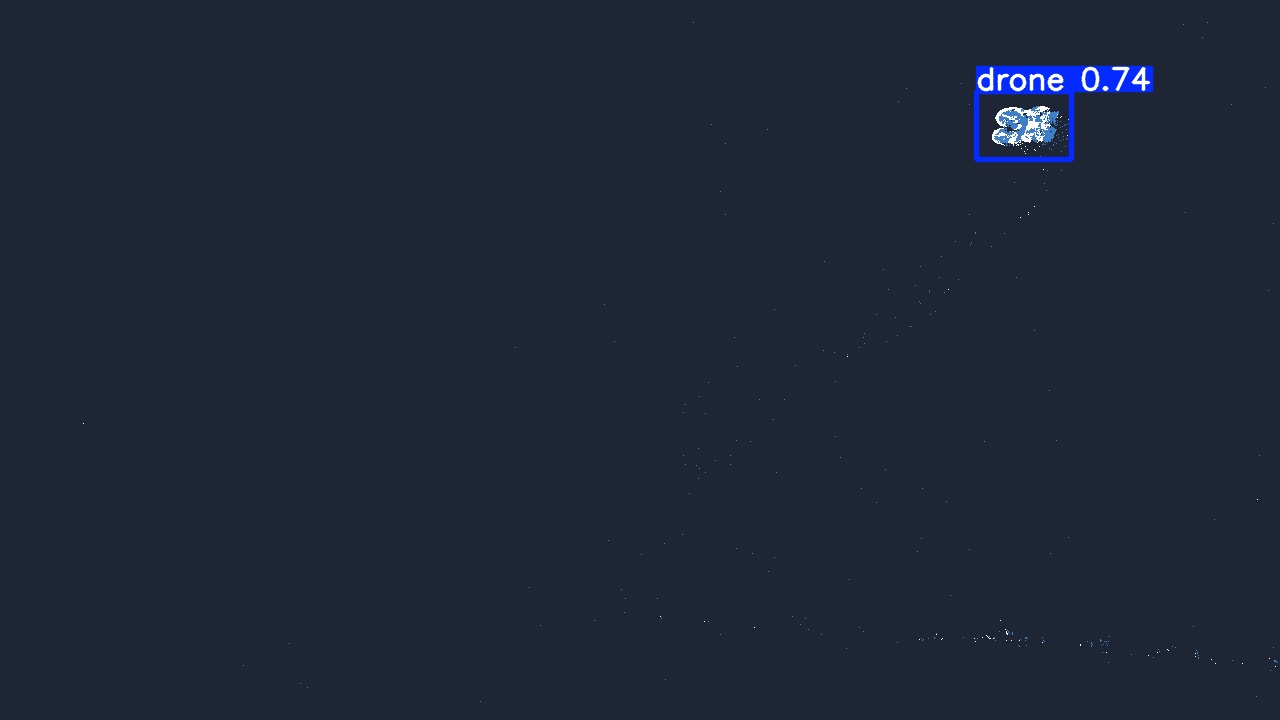

Error: Predicted image not found at expected path: /content/runs/detect/predict_image_13/Video_0_frame_103832295.png
Found image at: /content/runs/detect/predict_image_13/Video_0_frame_103832295.jpg. Displaying this one instead.


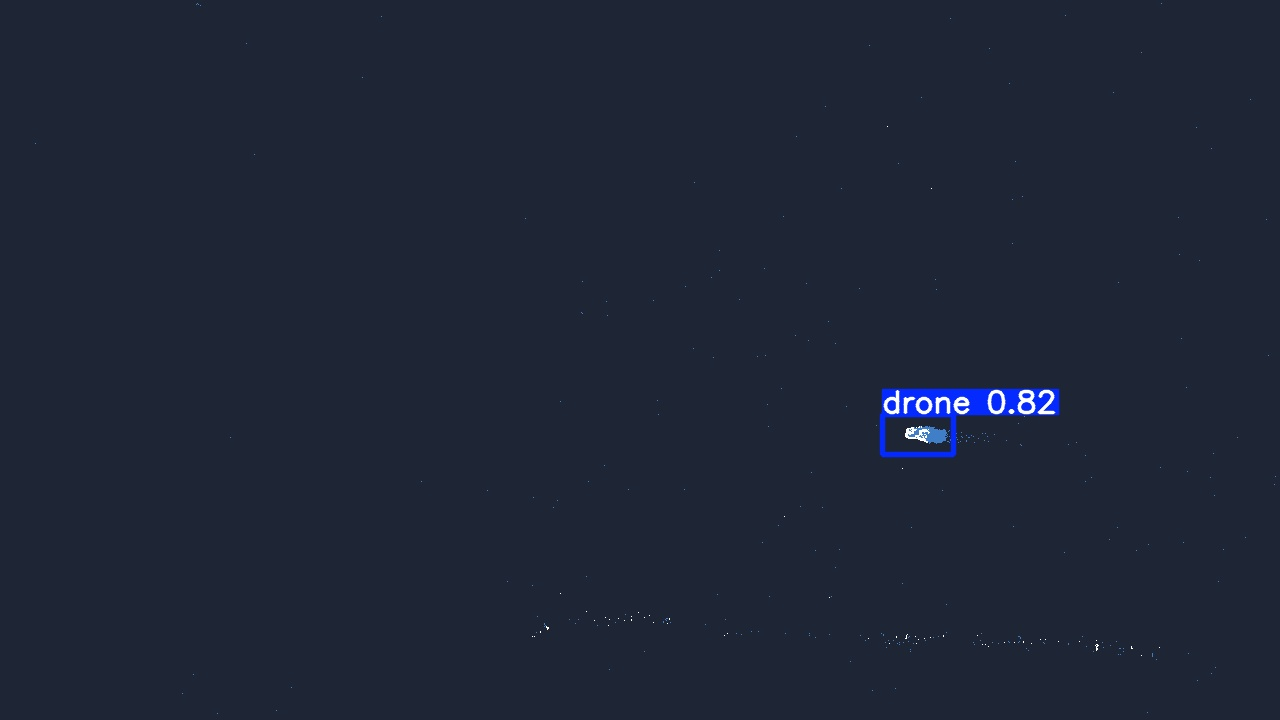

Error: Predicted image not found at expected path: /content/runs/detect/predict_image_23/Video_3_frame_20499795.png
Found image at: /content/runs/detect/predict_image_23/Video_3_frame_20499795.jpg. Displaying this one instead.


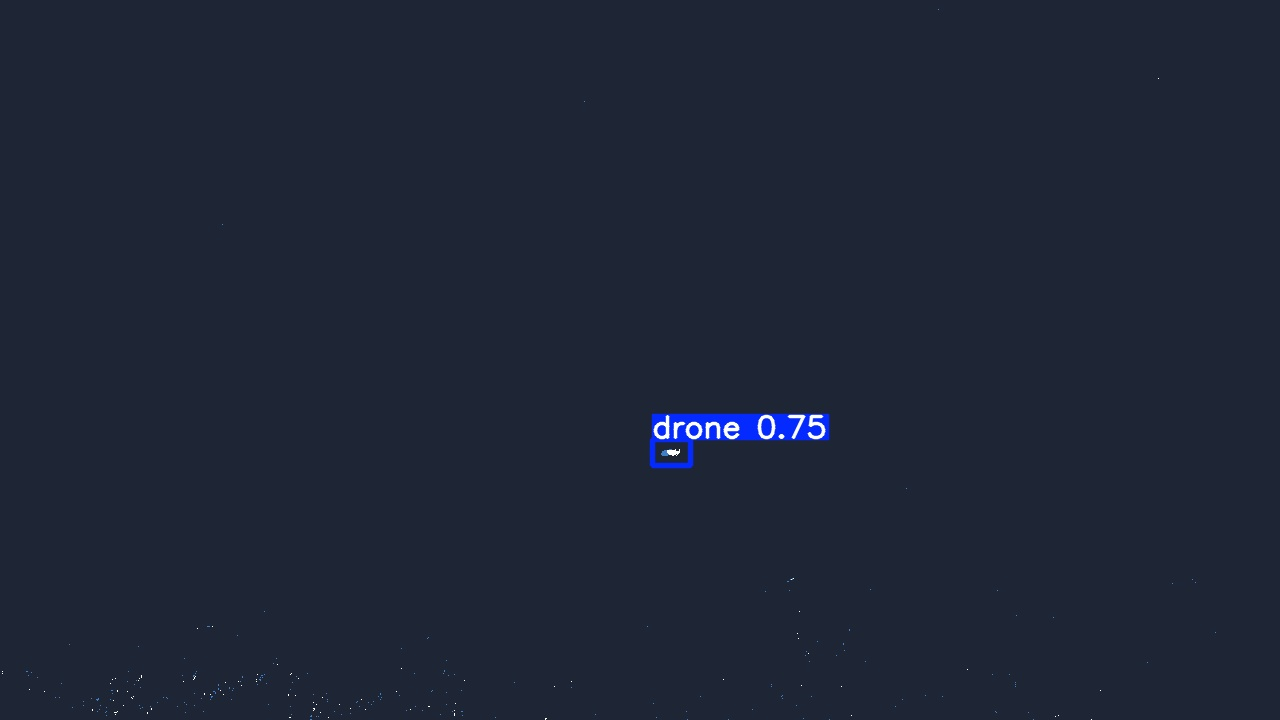

In [ ]:
from ultralytics import YOLO
import glob
from IPython.display import Image, display
import os

# 1. On charge le best modèle
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. On prend quelques images du dossier TEST
test_images = glob.glob('/content/dataset_split/dataset_split/images/test/*.png')[:3] # On en prend 3 au hasard

# 3. On demande au modèle de prédire
all_prediction_results = [] # List to store results from all predictions
for i, img_path in enumerate(test_images):
    # conf=0.25 : On affiche seulement si l'IA est sûre à au moins 25%
    # save=True : On sauvegarde l'image avec la boîte dessinée
    # Use 'name' parameter to create unique prediction directories for each image
    # This prevents overwriting of results if multiple predict calls use the same base directory.
    prediction_run_name = f"predict_image_{i}" # Unique name for each prediction run
    results_for_current_image = model.predict(source=img_path, conf=0.25, save=True, name=prediction_run_name)
    all_prediction_results.extend(results_for_current_image) # Add results to the collective list

# 4. On affiche les résultats ici
print("\n--- RÉSULTATS VISUELS ---")
for result in all_prediction_results: # Iterate through all collected results
    # The save_dir attribute of the result object correctly points to the specific directory
    save_directory = result.save_dir
    original_image_filename = os.path.basename(result.path)
    predicted_image_path = os.path.join(save_directory, original_image_filename)

    # Check if the predicted image file actually exists before trying to display it
    if os.path.exists(predicted_image_path):
        display(Image(filename=predicted_image_path, width=600))
    else:
        print(f"Error: Predicted image not found at expected path: {predicted_image_path}")
        # Let's try to find any image file in the save_directory
        found_images = glob.glob(os.path.join(save_directory, "*.png")) + \
                       glob.glob(os.path.join(save_directory, "*.jpg")) + \
                       glob.glob(os.path.join(save_directory, "*.jpeg"))
        if found_images:
            # Assume the first found image is the one we want to display
            display_image_path = found_images[0]
            print(f"Found image at: {display_image_path}. Displaying this one instead.")
            display(Image(filename=display_image_path, width=600))
        else:
            print(f"No image files found in {save_directory}. Directory contents: {os.listdir(save_directory) if os.path.isdir(save_directory) else 'Directory does not exist.'}")


In [ ]:
import shutil

# Chemin source (dans le Colab temporaire)
source_model = '/content/runs/detect/train/weights/best.pt'

# Chemin destination (dans ton Drive permanent)
# Change 'Projet_Drone' par le nom de ton dossier sur le Drive
dest_model = '/content/drive/MyDrive/portion_fred/mon_modele_drone_v1.pt'

shutil.copy(source_model, dest_model)

print(f"Modèle sauvegardé en sécurité ici : {dest_model}")

Modèle sauvegardé en sécurité ici : /content/drive/MyDrive/portion_fred/mon_modele_drone_v1.pt
